# Team Synthesis

In [104]:
from typing import Any

from kirin.ir import Method
import matplotlib.pyplot as plt
import numpy as np

from bloqade import squin, tsim
from bloqade.cirq_utils import emit_circuit, load_circuit, noise
from bloqade.pyqrack import StackMemorySimulator
from bloqade.types import MeasurementResult, Qubit
from kirin.dialects.ilist import IList
import matplotlib.pyplot as plt

# this will help us have return types for our methods that have more intuitive names
Register = IList[Qubit, Any]
Measurement = IList[MeasurementResult, Any]

# this function will help us visualize some circuits
def show_circuit(squin_kernel):
    @squin.kernel
    def _to_visualize():
        _ = squin_kernel()

    return tsim.Circuit(_to_visualize).diagram(height=400)

## Part 1: Learn the language of Clifford+$T$


Learn how to build and simulate simple circuits using Bloqade Squin and Bloqade PyQrack.

Build a few small 1-qubit and 2-qubit examples. Confirm that you understand how $H, S, $ and $CNOT$ act on simple input states. Use this part to get comfortable creating, simulating, and visualizing circuits constructed from the Clifford+$T := {H, S, CNOT, T}$ gateset.

Goal: Build intuition for Clifford+T circuits and the simulation workflow.

In [105]:
@squin.kernel
def bell_state() -> Measurement:
    qubits = squin.qalloc(2)
    squin.h(qubits[0])
    squin.cx(qubits[0], qubits[1])
    bits = squin.broadcast.measure(qubits)
    return bits

In [106]:
show_circuit(bell_state)

In [107]:
pyqrack_target = StackMemorySimulator(min_qubits=2)
task = pyqrack_target.task(bell_state)

single_shot = task.run()
single_shot

IList([<Measurement.Zero: 0>, <Measurement.Zero: 0>])

In [108]:
batch_results = task.batch_run(shots=2000)
batch_results

{(<Measurement.Zero: 0>, <Measurement.Zero: 0>): 0.4995,
 (<Measurement.One: 1>, <Measurement.One: 1>): 0.5005}

## Part 2: Synthesize the rotation family

Focus on the family

$$
R_z\left(\pi / 2^n\right), \qquad n \in 0,1,2,3,4,5
$$

How can we implement these “dyadic” Z-rotations using only Clifford+$T$?

Try synthesizing these rotations as well as you can using only our chosen gate set for one qubit (yes, only 1 qubit), and different values of \(n\). Some implementations may be exact while others may involve approximations, that is okay. It is up to you to explore different synthesis strategies and compare the circuits you find.

We suggest spending time on finding ways to visualize how your approximations act on different initial states, and reflecting on what you tried, how you judged quality, and what changed as the target angle became smaller.

**Goal**: Explore how small Z-rotations can be built from Clifford+ \(T\) and explain the synthesis strategies you explored.

**Distance metric**: When comparing a target gate \(U\) to an implementation \(V\), use the following global-phase-invariant distance:

$$
d(U,V) = \sqrt{1 - \frac{|\mathrm{Tr}(U^\dagger V)|}{2}}
$$

**Interpretation**
- \(d = 0\) means exact agreement up to global phase,
- larger \(d\) means a worse approximation.

In [109]:
H = np.array([[1, 1], [1, -1]]) / np.sqrt(2)
T = np.array([[1, 0], [0, np.exp(1j * np.pi / 4)]])
HT = H @ T
TT = T @ T
TTTT = TT @ TT
HTHT = HT @ HT

gates = {
    "H": H,
    "T": T,
    "HT": HT, 
    "TT": TT,
    "TTTT": TTTT,
    "HTHT": HTHT
}

def rz(theta):
    return np.array([[np.exp(-1j * theta / 2), 0], [0, np.exp(1j * theta / 2)]])

def distance(U, V):
    return np.sqrt(1 - abs(np.trace(U.conj().T @ V)) / 2)

In [110]:
from itertools import product

def brute_force(n, max_depth):
    best_seq = None
    best_d = float('inf') #distance(np.eye(2), rz(np.pi / 8))
    best_U = None

    U = rz(np.pi / (2**n))

    #for depth in range(1, max_depth + 1):
    for seq in product(gates.keys(), repeat=depth):
        #print(f"Trying sequence: {seq}")
        if any(a == "H" and b == "H" for a, b in zip(seq, seq[1:])):
            continue
        if "T" * 8 in "".join(seq):
            continue
        V = np.eye(2, dtype=complex)
        for gate in seq: V = gates[gate] @ V
        d = distance(U, V)

        if d < best_d:
            best_d = d
            best_seq = seq
            best_U = V

    return best_seq, best_d, best_U

In [111]:
for depth in range(1, 6):
    seq, d, U = brute_force(5, max_depth=depth)
    print(f"Depth: {depth}, Sequence: {seq}, Distance: {d:.6f}")

Depth: 1, Sequence: ('T',), Distance: 0.241777
Depth: 2, Sequence: ('HT', 'H'), Distance: 0.241777
Depth: 3, Sequence: ('HT', 'HTHT', 'HTHT'), Distance: 0.167024
Depth: 4, Sequence: ('H', 'HTHT', 'HTHT', 'T'), Distance: 0.167024
Depth: 5, Sequence: ('H', 'T', 'TT', 'TTTT', 'HT'), Distance: 0.034707


In [114]:
data = {"1": None, "2": None, "3": None, "4": None, "5": None}
for n in data.keys():
    print(f"Processing n={n}...")
    data[n] = dict()
    for depth in range(1, 10):
        print(f"  Depth: {depth}...")
        seq, d, U = brute_force(int(n), max_depth=depth)
        data[n][len("".join(seq))] = d, seq

Processing n=1...
  Depth: 1...
  Depth: 2...
  Depth: 3...
  Depth: 4...
  Depth: 5...
  Depth: 6...


C:\Users\Mar Li\AppData\Local\Temp\ipykernel_16768\3145263358.py:21: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(1 - abs(np.trace(U.conj().T @ V)) / 2)


  Depth: 7...
  Depth: 8...
  Depth: 9...
Processing n=2...
  Depth: 1...
  Depth: 2...
  Depth: 3...
  Depth: 4...
  Depth: 5...
  Depth: 6...
  Depth: 7...
  Depth: 8...
  Depth: 9...
Processing n=3...
  Depth: 1...
  Depth: 2...
  Depth: 3...
  Depth: 4...
  Depth: 5...
  Depth: 6...
  Depth: 7...
  Depth: 8...
  Depth: 9...
Processing n=4...
  Depth: 1...
  Depth: 2...
  Depth: 3...
  Depth: 4...
  Depth: 5...
  Depth: 6...
  Depth: 7...
  Depth: 8...
  Depth: 9...
Processing n=5...
  Depth: 1...
  Depth: 2...
  Depth: 3...
  Depth: 4...
  Depth: 5...
  Depth: 6...
  Depth: 7...
  Depth: 8...
  Depth: 9...


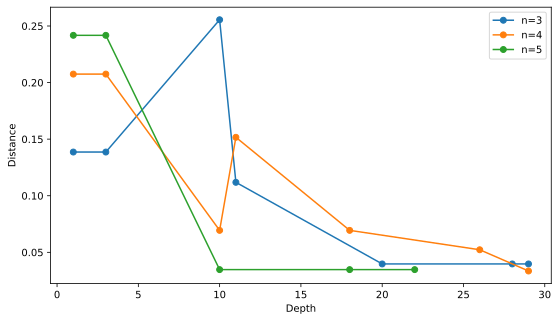

In [133]:
fig = plt.figure(figsize=(9, 5))

for n, results in data.items():
    if n == "1" or n == "2":
        continue
    #plt.axhline(y=distance(np.eye(2), rz(np.pi / (2**int(n)))), color='r', linestyle='--')
    depths = sorted(results.keys())
    distances = [results[d][0] for d in depths]
    plt.plot(depths, distances, marker='o', label=f"n={n}")

plt.xlabel("Depth")
plt.ylabel("Distance")
plt.legend()
plt.show()

## Team Synthesis Part 3: Non-Clifford gates are expensive

How would you approximate the family of rotations above if I now suddenly told you that $T$ gates can no longer be applied to your qubit? If you spent enough time thinking about part 1, the correct answer should be somewhere in the realm of "not good." Unfortunately, this is what often happens in reality (you will learn more about why this happens in the next part). It is up to you to find and implement a protocol to "inject" the effect of $T$ gates onto the main qubit.

To counteract this not-good news, you will now have access to auxiliary qubits on which you will be allowed to apply $T$ gates. You will now also be able to apply $CNOT$ gates using your main qubit as either target or control, as well as across auxiliary qubits. Other than that, it should be just $S$ or $H$ gates on your main qubit. We want you to approximate the rotations on your main qubit and benchmark them using the previous distance metric, working within the bounds of the simulators (i.e. if the circuit cannot be simulated the approximation does not count).

Track the new costs that appear: ancilla count, 2-qubit gate count, circuit depth, repeated trials, feed-forward, or any other relevant overhead.

Goal: Rebuild the same 1-qubit rotations in a setting where the non-Clifford gates in the Clifford+$T$ set must be supplied indirectly.



In [289]:
ry_angle = np.random.uniform(0, 2 * np.pi)
rz_angle = np.random.uniform(0, 2 * np.pi)

def make_psi(ry_angle, rz_angle):
    
    @squin.kernel
    def psi() -> Register:
        qubits = squin.qalloc(1)
        squin.ry(ry_angle, qubits[0])
        squin.rz(rz_angle, qubits[0])
        return qubits    
    return psi


show_circuit(make_psi(ry_angle, rz_angle))

In [290]:
def make_magic_state():
    @squin.kernel
    def magic_state() -> Register:
        qubits = squin.qalloc(1)
        squin.h(qubits[0])
        squin.t(qubits[0])
        return qubits    
    return magic_state

show_circuit(make_magic_state())

In [291]:
def make_injection(psi):
    aux_kernel = make_magic_state()
    
    @squin.kernel
    def injection() -> Register:
        main = psi()
        aux = aux_kernel()
        
        squin.cx(main[0], aux[0])
        
        measurement = squin.broadcast.measure([aux[0]]) 
        if measurement[0]:  
            squin.s(main[0])
        bits = squin.broadcast.measure(main)
        return bits
        
    return injection

In [292]:
pyqrack_target = StackMemorySimulator(min_qubits=1)
task = pyqrack_target.task(make_injection(make_psi(np.random.uniform(0, 2 * np.pi), np.random.uniform(0, 2 * np.pi))))
batch_results = task.batch_run(shots=500)
batch_results

{(<Measurement.One: 1>,): 0.926, (<Measurement.Zero: 0>,): 0.074}

In [293]:
def make_T_circuit(psi):
    
    @squin.kernel
    def T_circuit() -> Measurement:
        qubits = psi()
        squin.t(qubits[0])
        bits = squin.broadcast.measure(qubits)
        return bits
    
    return T_circuit

psi = make_psi(np.random.uniform(0, 2 * np.pi), np.random.uniform(0, 2 * np.pi))
show_circuit(make_T_circuit(psi))

In [294]:
pyqrack_target = StackMemorySimulator(min_qubits=1)
task = pyqrack_target.task(make_T_circuit(make_psi(np.random.uniform(0, 2 * np.pi), np.random.uniform(0, 2 * np.pi))))
batch_results = task.batch_run(shots=500)
print(batch_results)
def outcome_to_bitstring(outcome):
    return "".join("1" if getattr(x,"value",None)==1 or "One" in repr(x) else "0" for x in outcome)
counts = { outcome_to_bitstring(k): v for k,v in batch_results.items() }
print(counts) 

{(<Measurement.Zero: 0>,): 0.986, (<Measurement.One: 1>,): 0.014}
{'0': 0.986, '1': 0.014}


In [295]:
data = {"T": [], "Injection": []}

for _ in range(15):
    ry_angle = np.random.uniform(0, 2*np.pi)
    rz_angle = np.random.uniform(0, 2*np.pi)
    psi = make_psi(ry_angle, rz_angle)

    pyqrack_target_T = StackMemorySimulator(min_qubits=1)
    task_T = pyqrack_target_T.task(make_T_circuit(psi))
    batch_results_T = task_T.batch_run(shots=500)
    batch_results_T = { outcome_to_bitstring(k): v for k,v in batch_results_T.items() }
    if "0" not in batch_results_T:
        batch_results_T["0"] = 0.0
    if "1" not in batch_results_T:
        batch_results_T["1"] = 0.0
    a_T, b_T = batch_results_T["0"], batch_results_T["1"]
    data["T"].append((a_T, b_T))

    pyqrack_target_injection = StackMemorySimulator(min_qubits=2)
    task_injection = pyqrack_target_injection.task(make_injection(psi))
    batch_results_injection = task_injection.batch_run(shots=600)
    batch_results_injection = { outcome_to_bitstring(k): v for k,v in batch_results_injection.items() }
    if "0" not in batch_results_injection:
        batch_results_injection["0"] = 0.0
    if "1" not in batch_results_injection:
        batch_results_injection["1"] = 0.0
    a_injection, b_injection = batch_results_injection["0"], batch_results_injection["1"]
    data["Injection"].append((a_injection, b_injection))


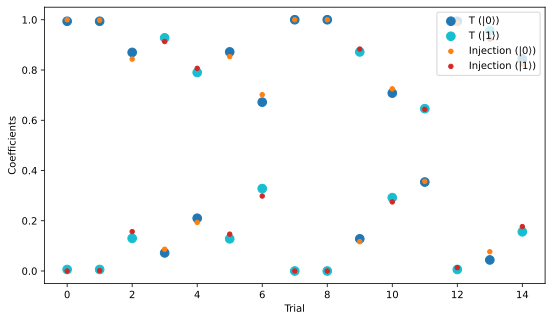

In [296]:
fig = plt.figure(figsize=(9, 5))
for method, results in data.items():
    if method == "T": 
        colors = ["tab:blue", "tab:cyan"]
        size = 75
    if method == "Injection": 
        colors = ["tab:orange", "tab:red"]
        size = 20
    a_values = [res[0] for res in results]
    b_values = [res[1] for res in results]
    plt.scatter([t for t in range(len(a_values))], a_values, color=colors[0], s=size, label=fr"{method} ($|0\rangle$)")
    plt.scatter([t for t in range(len(b_values))], b_values, color=colors[1], s=size, label=fr"{method} ($|1\rangle$)")

plt.xlabel("Trial")
plt.ylabel("Coefficients")
plt.legend(loc="upper right")
plt.show()

In [297]:
seq, d, U = brute_force(10, max_depth=depth)
seq = "".join(seq)
print(f"Depth: {depth}, Sequence: {seq}, Distance: {d:.6f}")

Depth: 5, Sequence: HTTTTTTTHT, Distance: 0.001085


In [298]:
def brute_force_circuit_with_T(psi, sequence):    
    @squin.kernel
    def brute_force_circuit() -> Register:
        qubits = psi()
        for gate in sequence:
            if gate == "H": squin.h(qubits[0])
            elif gate == "T": squin.t(qubits[0])

        mid_circuit_measurement = squin.broadcast.measure(qubits)
        
        return mid_circuit_measurement
    return brute_force_circuit

show_circuit(brute_force_circuit_with_T(make_psi(ry_angle, rz_angle), sequence=seq))

In [299]:
pyqrack_target = StackMemorySimulator(min_qubits=1)
psi = make_psi(np.random.uniform(0, 2 * np.pi), np.random.uniform(0, 2 * np.pi))
task = pyqrack_target.task(brute_force_circuit_with_T(psi, sequence=seq))
batch_results = task.batch_run(shots=500)
print(batch_results)

{(<Measurement.One: 1>,): 0.884, (<Measurement.Zero: 0>,): 0.116}


In [300]:
def brute_force_circuit_without_T(psi, sequence):    
    aux_kernel = make_magic_state()
    @squin.kernel
    def brute_force_circuit() -> Register:
        main = psi()
        aux = aux_kernel()

        for gate in sequence:
            if gate == "H": squin.h(main[0])
            elif gate == "T":
                squin.cx(main[0], aux[0])
                measurement = squin.broadcast.measure([aux[0]]) 
                if measurement[0]:  
                    squin.s(main[0])
        bits = squin.broadcast.measure(main)
        return bits
    return brute_force_circuit

In [301]:
pyqrack_target = StackMemorySimulator(min_qubits=1)
psi = make_psi(np.random.uniform(0, 2 * np.pi), np.random.uniform(0, 2 * np.pi))
task = pyqrack_target.task(brute_force_circuit_with_T(psi, sequence=seq))
batch_results = task.batch_run(shots=500)
print(batch_results)

{(<Measurement.One: 1>,): 0.304, (<Measurement.Zero: 0>,): 0.696}


In [302]:
def rz_circuit(psi, n):
    @squin.kernel
    def circuit() -> Measurement:
        qubits = psi()
        squin.rz(np.pi/(2**n), qubits[0])
        bits = squin.broadcast.measure(qubits)
        return bits
    return circuit

show_circuit(rz_circuit(make_psi(ry_angle, rz_angle), 3))

In [345]:
data = {"RZ": {}, "T": {}, "Injection": {}}

for n in range(1, 6):
    print(f"Processing n={n}...")

    data["T"][n] = []
    data["Injection"][n] = []
    data["RZ"][n] = []

    seq, d, U = brute_force(10, max_depth=depth)
    seq = "".join(seq)
    print(f"Depth: {depth}, Sequence: {seq}, Distance: {d:.6f}")

    for _ in range(5):
        print(f"  Trial {_+1}...")
        ry_angle = np.random.uniform(0, 2*np.pi)
        rz_angle = np.random.uniform(0, 2*np.pi)
        psi = make_psi(ry_angle, rz_angle)

        pyqrack_target_exact = StackMemorySimulator(min_qubits=2)
        task_exact = pyqrack_target_exact.task(rz_circuit(psi, n))
        batch_results_exact = task_exact.batch_run(shots=600)
        batch_results_exact = { outcome_to_bitstring(k): v for k,v in batch_results_exact.items() }
        if "0" not in batch_results_exact:
            batch_results_exact["0"] = 0.0
        if "1" not in batch_results_exact:
            batch_results_exact["1"] = 0.0
        a_exact, b_exact = batch_results_exact["0"], batch_results_exact["1"]
        data["RZ"][n].append((a_exact, b_exact))

        pyqrack_target_T = StackMemorySimulator(min_qubits=1)
        task_T = pyqrack_target_T.task(brute_force_circuit_with_T(psi, sequence=seq))
        batch_results_T = task_T.batch_run(shots=600)
        batch_results_T = { outcome_to_bitstring(k): v for k,v in batch_results_T.items() }
        if "0" not in batch_results_T:
            batch_results_T["0"] = 0.0
        if "1" not in batch_results_T:
            batch_results_T["1"] = 0.0
        a_T, b_T = batch_results_T["0"], batch_results_T["1"]
        data["T"][n].append((a_T, b_T))

        pyqrack_target_injection = StackMemorySimulator(min_qubits=2)
        task_injection = pyqrack_target_injection.task(brute_force_circuit_without_T(psi, sequence=seq))
        batch_results_injection = task_injection.batch_run(shots=600)
        batch_results_injection = { outcome_to_bitstring(k): v for k,v in batch_results_injection.items() }
        if "0" not in batch_results_injection:
            batch_results_injection["0"] = 0.0
        if "1" not in batch_results_injection:
            batch_results_injection["1"] = 0.0
        a_injection, b_injection = batch_results_injection["0"], batch_results_injection["1"]
        data["Injection"][n].append((a_injection, b_injection))

Processing n=1...
Depth: 5, Sequence: HTTTTTTTHT, Distance: 0.001085
  Trial 1...
  Trial 2...
  Trial 3...
  Trial 4...
  Trial 5...
Processing n=2...
Depth: 5, Sequence: HTTTTTTTHT, Distance: 0.001085
  Trial 1...
  Trial 2...
  Trial 3...
  Trial 4...
  Trial 5...
Processing n=3...
Depth: 5, Sequence: HTTTTTTTHT, Distance: 0.001085
  Trial 1...
  Trial 2...
  Trial 3...
  Trial 4...
  Trial 5...
Processing n=4...
Depth: 5, Sequence: HTTTTTTTHT, Distance: 0.001085
  Trial 1...
  Trial 2...
  Trial 3...
  Trial 4...
  Trial 5...
Processing n=5...
Depth: 5, Sequence: HTTTTTTTHT, Distance: 0.001085
  Trial 1...
  Trial 2...
  Trial 3...
  Trial 4...
  Trial 5...


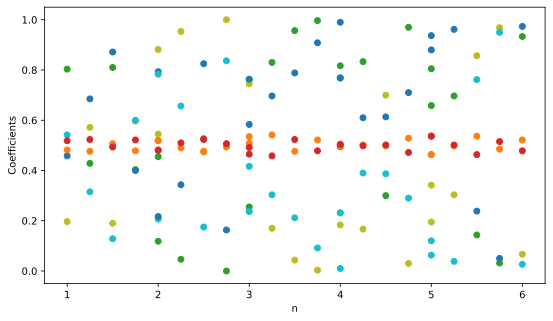

In [346]:
fig = plt.figure(figsize=(9, 5))
for method, results in data.items():
    if method == "T": 
        colors = ["tab:blue", "tab:cyan"]
        #size = 50
    if method == "Injection": 
        colors = ["tab:orange", "tab:red"]
        #size = 20
    if method == "RZ":
        colors = ["tab:green", "tab:olive"]
        #size = 75
    
    for n, res in results.items():
        a_values = [r[0] for r in res]
        b_values = [r[1] for r in res]
        plt.scatter(np.linspace(n, n+1, len(a_values)), a_values, color=colors[0], label=fr"{method} ($|0\rangle$)")
        plt.scatter(np.linspace(n, n+1, len(b_values)), b_values, color=colors[1], label=fr"{method} ($|1\rangle$)")

plt.xlabel("n")
plt.ylabel("Coefficients")
plt.show()